Programme: PGDip Applied Data Analytics<br>
Course: PROJC9013 Project Interim Report<br>
Student: D00285895 George Semain

# **A prototype retrieval-based question and answering system based on a corpus of publicly available regulatory documents**

### **Step 1: Gather Data**

Ten example regulatory documents have been downloaded from the EUR-Lex site on which to preform basic Exploratory Data Analysis.

### **Step 2: Import Data**

The ten PDF documents were saved in a folder in Google Drive 'DKIT_PROJC9013_Interim'.<br>
The Google drive was connected to Google.Colab (once access permission was granted the confirmation message 'mounted at /content/drive' confirmed this was successful.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Validate that there is access to the MyDrive folder containing the ten PDF source files.

In [2]:
import os
mydrive_path = "/content/drive/MyDrive/DKIT_PROJC9013_Interim"
os.listdir(mydrive_path)

['Test05.pdf',
 'Test06.pdf',
 'Test07.pdf',
 'Test04.pdf',
 'Test10.pdf',
 'Test08.pdf',
 'Test09.pdf',
 'Test03.pdf',
 'Test02.pdf',
 'Test01.pdf']

Create a list of the ten PDF source filenames.

In [3]:
doc_files = [
    f for f in os.listdir(mydrive_path)
    if f.lower().endswith(".pdf")
]

In [4]:
doc_files

['Test05.pdf',
 'Test06.pdf',
 'Test07.pdf',
 'Test04.pdf',
 'Test10.pdf',
 'Test08.pdf',
 'Test09.pdf',
 'Test03.pdf',
 'Test02.pdf',
 'Test01.pdf']

Create a dataframe to store document metadata. Store the filename in each case.

In [5]:
import pandas as pd

metadata = pd.DataFrame({
    "file_name": doc_files
})

In [6]:
metadata

,file_name
0,Test05.pdf
1,Test06.pdf
2,Test07.pdf
3,Test04.pdf
4,Test10.pdf
5,Test08.pdf
6,Test09.pdf
7,Test03.pdf
8,Test02.pdf
9,Test01.pdf


Define additional metadata attributes to give each document a unique identification code (automatically incrementing each time), and to store the company name and document title. Additional metrics will be added later as part of EDA.

In [7]:
metadata["doc_id"] = [f"doc_{i+1:02d}" for i in range(len(metadata))]
metadata["source"] = "EUR-Lex"

In [8]:
metadata

,file_name,doc_id,source
0,Test05.pdf,doc_01,EUR-Lex
1,Test06.pdf,doc_02,EUR-Lex
2,Test07.pdf,doc_03,EUR-Lex
3,Test04.pdf,doc_04,EUR-Lex
4,Test10.pdf,doc_05,EUR-Lex
5,Test08.pdf,doc_06,EUR-Lex
6,Test09.pdf,doc_07,EUR-Lex
7,Test03.pdf,doc_08,EUR-Lex
8,Test02.pdf,doc_09,EUR-Lex
9,Test01.pdf,doc_10,EUR-Lex


In ordr to extract document text to perform analysis, 'pdfplumber' can be used to read PDF files.

In [9]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 68.2 MB/s eta 0:00:00


Test reading the text from the first page of the first PDF file.
The first page of Test05.pdf looks like this:
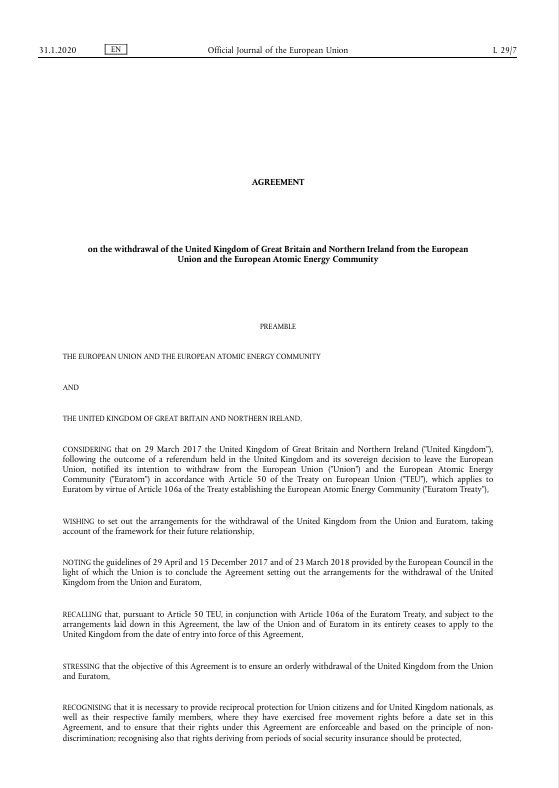

In [10]:
import pdfplumber
import numpy as np

test_file = doc_files[0] # first file listed in the folder
test_path = f"{mydrive_path}/{test_file}"

with pdfplumber.open(test_path) as pdf:
    print("Number of pages:", len(pdf.pages))
    first_page_text = pdf.pages[0].extract_text()
    print(test_file, first_page_text)

Number of pages: 181
Test05.pdf 31.1.2020 E N O f f i c i a l J o u r n a l o f t h e E u r o p e a n U nion L 29/7
AGREEMENT
on the withdrawal of the United Kingdom of Great Britain and Northern Ireland from the European
Union and the European Atomic Energy Community
PREAMBLE
THE EUROPEAN UNION AND THE EUROPEAN ATOMIC ENERGY COMMUNITY
AND
THE UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND,
CONSIDERING that on 29 March 2017 the United Kingdom of Great Britain and Northern Ireland ("United Kingdom"),
following the outcome of a referendum held in the United Kingdom and its sovereign decision to leave the European
Union, notified its intention to withdraw from the European Union ("Union") and the European Atomic Energy
Community ("Euratom") in accordance with Article 50 of the Treaty on European Union ("TEU"), which applies to
Euratom by virtue of Article 106a of the Treaty establishing the European Atomic Energy Community ("Euratom Treaty"),
WISHING to set out the arrangements for 

Observations:

*   The page header text was extracted - although there is no way of knowing it is header text as opposed to normal page text. The formatting was not perfect.
*   It is possible to see a paragraph end, differentiated from a sentence end. There may be a 'carriage return' character that isn't clearly readable.
*   The text has been extracted accurately.

Having proven the ability to extract document text, the next stage is to iterate through each document, and determine basic document metrics:

*   number of pages (with text)
*   number of empty pages (no text)
*   word count
*   document text that has been extracted

The following function (already previously used in Machine Learning CA2) can be used to gather basic metrics on each document.

In [11]:
def extract_document_metrics(pdf_path):
    text_pages = [] # used to store the text on each page
    empty_pages = 0 # used to count teh number of empty pages

    with pdfplumber.open(pdf_path) as pdf:
        # process each page
        for page in pdf.pages:
            # extract teh text on teh page
            page_text = page.extract_text()
            # determine if its a blank page and if so increment teh empty page counter and set teh page text to be empty
            if page_text is None or page_text.strip() == "":
                empty_pages += 1
                text_pages.append("")
            # if not blank, add teh page text as a new string in text_pages
            else:
                text_pages.append(page_text)
    # concatenate all of teh text pages strings witha new line separating them
    full_text = "\n".join(text_pages)
    #use teh .split() method to separate teh full text into words (separating on spaces, tabs, new lines, ...)
    # and count the number of items (words) in teh list)
    word_count = len(full_text.split())

    return {
        "n_pages": len(text_pages),
        "empty_pages": empty_pages,
        "word_count": word_count,
        "text": full_text
    }

The following routine iterates through each filename and calls the 'extract_document_metrics()' function

In [12]:
extracted_results = []
#iterate through each file
for file_name in doc_files:
    file_path = f"{mydrive_path}/{file_name}"
    # in each case call teh function and return the data into metrics
    try:
        metrics = extract_document_metrics(file_path)
        # add teh filename
        metrics["file_name"] = file_name
        # add a boolean flag confirming teh document extraction routine completed successfuly
        metrics["extraction_success"] = True
    # if teh routine fails, store empty values for each metric with a boolean flag confirming extraction was not successful
    except Exception as e:
        metrics = {
            "file_name": file_name,
            "n_pages": np.nan,
            "empty_pages": np.nan,
            "word_count": np.nan,
            "text": "",
            "extraction_success": False
        }
    # append teh metrics to extracted_results
    extracted_results.append(metrics)

This took a few minutes to run as it is processing a lot of data.<br>
The next step is to store the appended metrics in a dataframe,

In [13]:
extracted_df = pd.DataFrame(extracted_results)

metadata = metadata.merge(
    # remove the column containing the detailed text
    extracted_df.drop(columns=["text"]),
    # merge where there is a match on file_name
    on="file_name",
    # keep existing metadat columsn for each filename
    how="left"
)

# show the dataframe
metadata

,file_name,doc_id,source,n_pages,empty_pages,word_count,extraction_success
0,Test05.pdf,doc_01,EUR-Lex,181,0,103895,True
1,Test06.pdf,doc_02,EUR-Lex,23,0,11641,True
2,Test07.pdf,doc_03,EUR-Lex,2,0,520,True
3,Test04.pdf,doc_04,EUR-Lex,18,0,7823,True
4,Test10.pdf,doc_05,EUR-Lex,88,0,55798,True
5,Test08.pdf,doc_06,EUR-Lex,20,0,12892,True
6,Test09.pdf,doc_07,EUR-Lex,36,0,28079,True
7,Test03.pdf,doc_08,EUR-Lex,111,0,65514,True
8,Test02.pdf,doc_09,EUR-Lex,90,0,55758,True
9,Test01.pdf,doc_10,EUR-Lex,22,0,12447,True


All ten documents appear to have processed successfuly. Each document was manually inspected and validated that the automatic number of pages calculated was correct.

In [14]:
pages_processed = metadata["n_pages"].sum()
total_words = metadata["word_count"].sum()
print(f"Pages processed: {pages_processed:,}")
print(f"Total words: {total_words:,}")


Pages processed: 591
Total words: 354,367


The extracted text was not saved to the metadata dataframe, instead will be saved to a csv file so that it can be read easily for future processing without having to extract the pdf files again. Each record will contain just the filename and the full extracted text string.

In [15]:
text_store = extracted_df[["file_name", "text"]]
text_store.to_csv("/content/drive/MyDrive/DKIT_PROJC9013_Interim/extracted_text.csv", index=False)

Checking Google Drive shows the csv file was saved.<br>

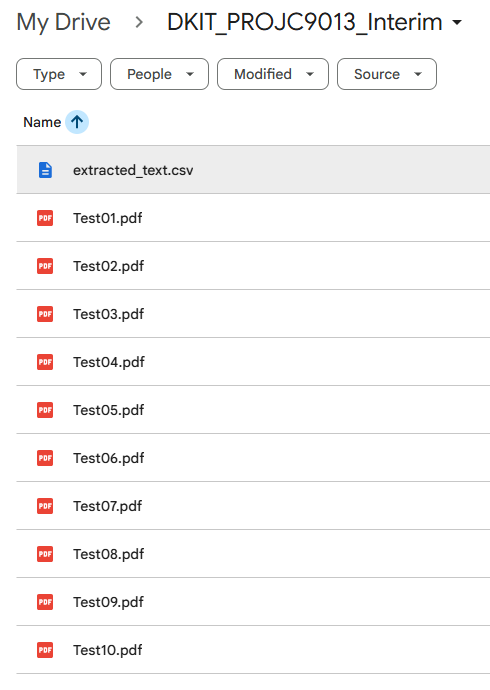

It is helpful to store the percentage of empty pages per document as a quality metric (albeit the number of empty pages is very low).

In [16]:
metadata["percent_empty_pages"] = (
    metadata["empty_pages"] / metadata["n_pages"]
) * 100

In [17]:
metadata

,file_name,doc_id,source,n_pages,empty_pages,word_count,extraction_success,percent_empty_pages
0,Test05.pdf,doc_01,EUR-Lex,181,0,103895,True,0.0
1,Test06.pdf,doc_02,EUR-Lex,23,0,11641,True,0.0
2,Test07.pdf,doc_03,EUR-Lex,2,0,520,True,0.0
3,Test04.pdf,doc_04,EUR-Lex,18,0,7823,True,0.0
4,Test10.pdf,doc_05,EUR-Lex,88,0,55798,True,0.0
5,Test08.pdf,doc_06,EUR-Lex,20,0,12892,True,0.0
6,Test09.pdf,doc_07,EUR-Lex,36,0,28079,True,0.0
7,Test03.pdf,doc_08,EUR-Lex,111,0,65514,True,0.0
8,Test02.pdf,doc_09,EUR-Lex,90,0,55758,True,0.0
9,Test01.pdf,doc_10,EUR-Lex,22,0,12447,True,0.0


In [18]:
percent_empty_pages = (metadata["percent_empty_pages"].sum() / metadata["n_pages"].sum()) * 100
print(f"Percentage of pages that are empty: {percent_empty_pages:,.2f}%")


Percentage of pages that are empty: 0.00%


Observations:

*   The method to extract text from PDF documents appears to be suitable to perform further EDA
*   The quality of the text extract appears to be very good - 0.02% empty pages can be considered negligible.



### **Step 3: Enrich Metadata**

There is significant metadata that can be downloaded from EUR-Lex that can be stored in the solution metadata directly. This is not required as part of this test but will be performed in the final solution as part of document ingestion.


### **Step 4: Descriptive Statistics**
The quantitative attributes of the metadata enable analysis of central tendency, variability & spread and range of values.

In [19]:
metadata[["n_pages", "word_count", "percent_empty_pages"]].describe()

,n_pages,word_count,percent_empty_pages
count,10.000000,10.000000,10.0
mean,59.100000,35436.700000,0.0
std,56.798768,33429.152022,0.0
min,2.000000,520.000000,0.0
25%,20.500000,11842.500000,0.0
50%,29.500000,20485.500000,0.0
75%,89.500000,55788.000000,0.0
max,181.000000,103895.000000,0.0


### **Step 5: Visualisations**
##### *<u>Distribution of Document Length (Pages)*</u>

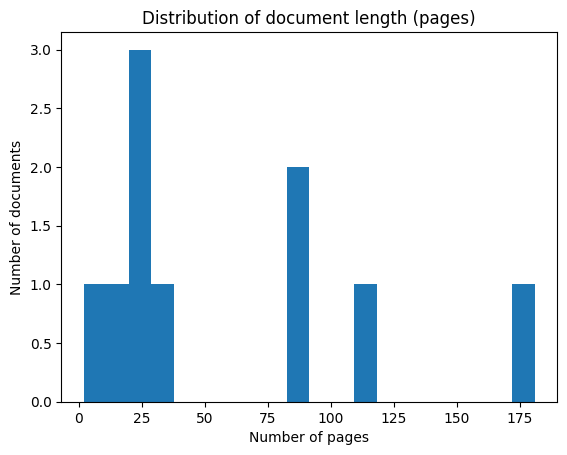

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(metadata["n_pages"], bins=20)
plt.xlabel("Number of pages")
plt.ylabel("Number of documents")
plt.title("Distribution of document length (pages)")
plt.show()

This clearly shows a variability in size of documents. There are only ten documents - the project will be limited to ~100 documents. The scaled production system will have many more.

##### *<u>Distribution of Document Length (Words)*</u>

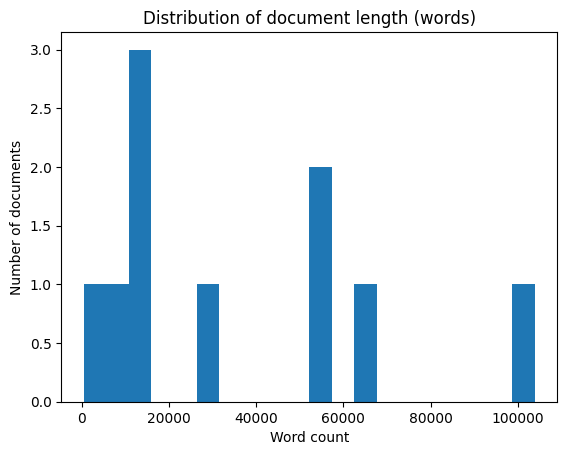

In [21]:
plt.figure()
plt.hist(metadata["word_count"], bins=20)
plt.xlabel("Word count")
plt.ylabel("Number of documents")
plt.title("Distribution of document length (words)")
plt.show()

The distribution of words appears to be consistent with the distribution of pages.

##### *<u>Variability of Document Length (Pages)*</u>

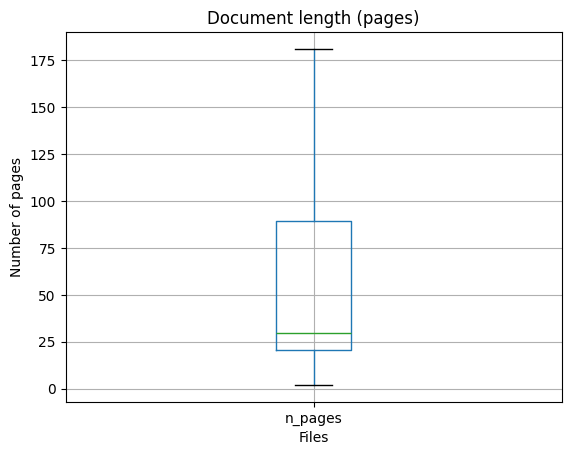

In [25]:
plt.figure()
metadata.boxplot(column="n_pages")
plt.xlabel("Files")
plt.ylabel("Number of pages")
plt.title("Document length (pages)")
plt.suptitle("")
plt.show()

##### *<u>Variability of Document Length (Words)*</u>

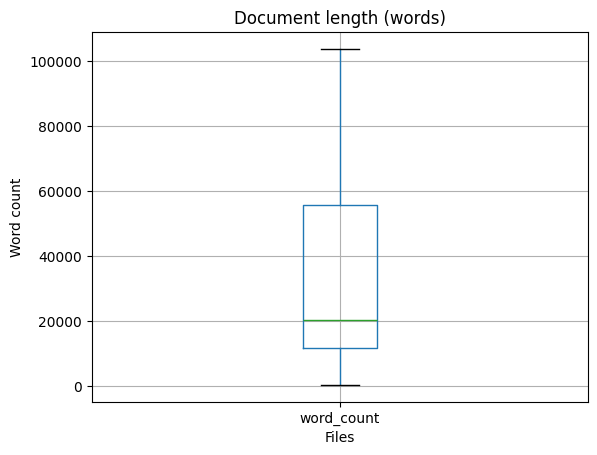

In [26]:
plt.figure()
metadata.boxplot(column="word_count")
plt.xlabel("Files")
plt.ylabel("Word count")
plt.title("Document length (words)")
plt.suptitle("")
plt.show()

There is variability in teh length of the random ten documents being explored. This is a very small sample so is unlikely to be representative of the complete regulatory document population on EUR-Lex.

##### *<u>Proportion of empty pages per document*</u>


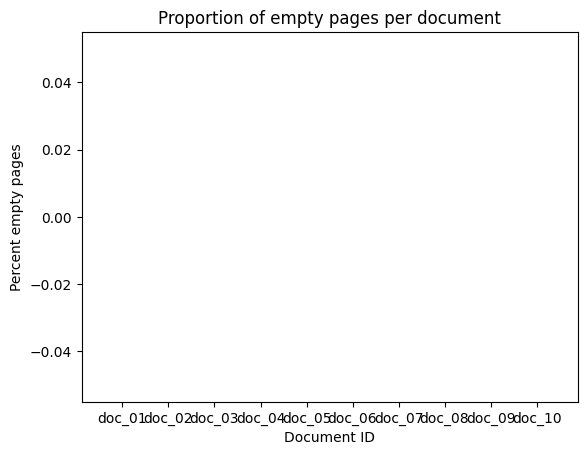

In [27]:
plt.figure()
plt.bar(metadata["doc_id"], metadata["percent_empty_pages"])
plt.xlabel("Document ID")
plt.ylabel("Percent empty pages")
plt.title("Proportion of empty pages per document")
plt.show()

No documents had empty pages processed as part of the text extraction.

### **Step 6: Words & Vocabulary Analysis**
In order to perform some further analysis of the 'language' of each document it is necessary, first, to merge the document text with the metadata.

In [29]:
text_df = pd.read_csv("/content/drive/MyDrive/DKIT_PROJC9013_Interim/extracted_text.csv")

text_df.head()

,file_name,text
0,Test05.pdf,31.1.2020 E N O f f i c i a l J o u r n a l o ...
1,Test06.pdf,17.4.2023 EN Official Journal of the European ...
2,Test07.pdf,L 102/84 EN Official Journal of the European U...
3,Test04.pdf,"EUROPEAN\nCOMMISSION\nBrussels, 24.1.2018\nCOM..."
4,Test10.pdf,4.5.2016 EN Official Journal of the European U...


In [30]:
# merge text with metadata (on filename)
doc_text = metadata.merge(text_df, on="file_name", how="left")

It is necessary to do some simple pre-processing prior to language analysis, to ensure accurate results and simplify the text being processed.

In [31]:
# import teh regular expressions library which enables some text cleaning
import re

# define teh function to clean teh text for analysis
def simple_preprocess(text):
    # convert all text to lower case - this ensures a word spelled teh same as any otehr word is treated as the same word
    text = text.lower()
    # replace any character that is not a lowercase letter or a space with a space (removes punctuation)
    text = re.sub(r"[^a-z\s]", " ", text)

    # replace any whitespace character, or string of white space characters, with a single space
    text = re.sub(r"\s+", " ", text)
    # remove any spaces at the start or end of teh text
    return text.strip()

#create a new column 'clean_text' in teh dataframe having run teh function
doc_text["clean_text"] = doc_text["text"].apply(simple_preprocess)


Note the basic pre-processing does not perform any lemmatisation of words to their root form.

##### *<u>Word frequency count</u>*

In [32]:
# import teh Counter data type so that its easy to count each word
from collections import Counter

# join teh six cleaned text strings with a space separator, and split it into a list of separate words
all_words = " ".join(doc_text["clean_text"]).split()

# count each word using a counter object
word_counts = Counter(all_words)

#create a dataframe of the 20 most common words across all six documents, noting teh word and the count
common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

# display teh 20 most common words and the number of times each appeared in the six docs
common_words

,word,count
0,the,31894
1,of,19987
2,to,11441
3,and,10679
4,in,8907
5,a,5728
6,or,5134
7,shall,3938
8,for,3566
9,article,3431


Observations:

*   There's a lot of common 'small' words like the, a, in, is, for, ... these are not very interesting
*   There's a lot of single letters
<br>
For meaningful insights as part of exploratory analysis, it is necessary to perform additional cleaning/pre-processing of the text.


*   Remove small words (known as 'stopwords')
*   Remove spurious letters



In [33]:
# scikitlearn has various tools for feature extraction from text (and converting to numerical data)ENGLISH_STOP_WORDS
# ENGLISH_STOP_WORDS is teh set of pre-defined small words
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)

# keep only words that are not in stopwprds and are >=3 characters
filtered_words = [
    w for w in all_words
    if w not in stopwords and len(w) >= 3
]

# count the new list of words
filtered_word_counts = Counter(filtered_words)

# create a new data frame for teh 20 most common words, after this additional processing
filtered_common_words = pd.DataFrame(
    filtered_word_counts.most_common(20),
    columns=["word", "count"]
)
# display the 20 most common words
filtered_common_words

,word,count
0,shall,3938
1,article,3431
2,union,2394
3,data,2301
4,authority,2212
5,regulation,1912
6,european,1883
7,information,1411
8,council,1385
9,member,1385


This is much more insightful and meaningful than before.

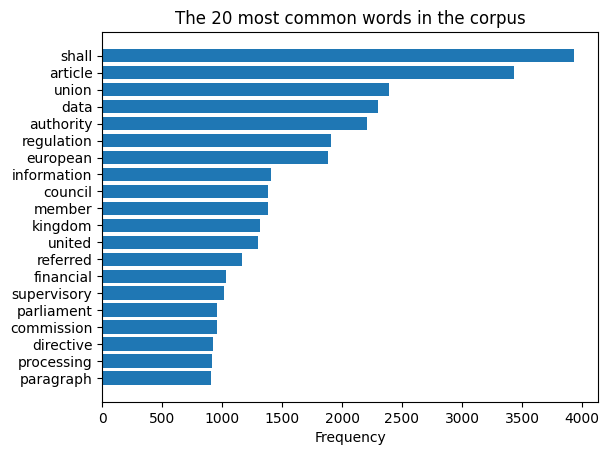

In [34]:
plt.figure()
plt.barh(
    filtered_common_words["word"],
    filtered_common_words["count"]
)
plt.xlabel("Frequency")
plt.title("The 20 most common words in the corpus")
plt.gca().invert_yaxis()
plt.show()

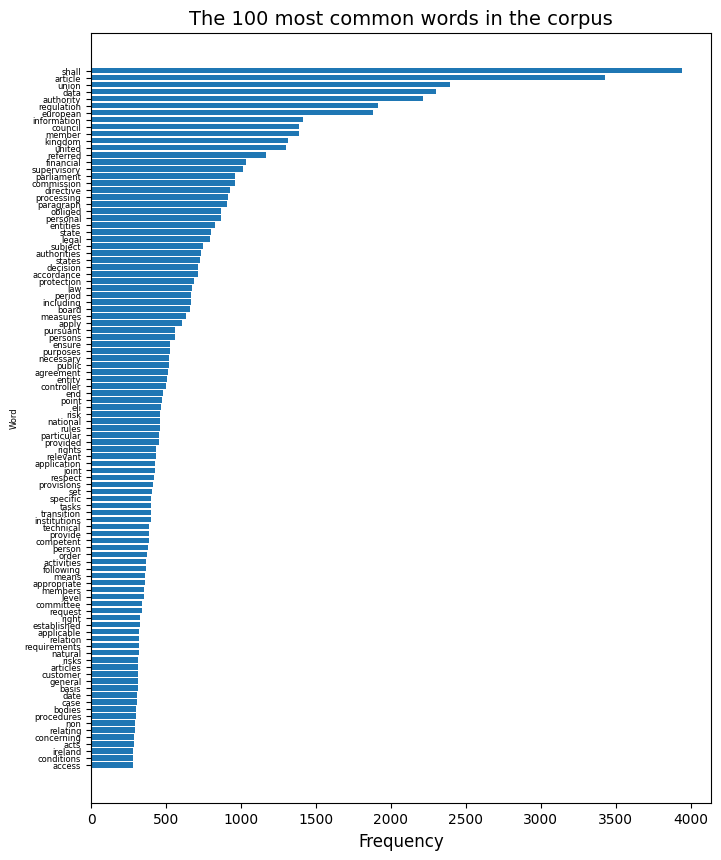

In [36]:
# repeat for the 100 most common words
filtered_common_words = pd.DataFrame(
    filtered_word_counts.most_common(100),
    columns=["word", "count"]
)

# Adjust teh size of teh plot
plt.figure(figsize=(8, 10))

plt.barh(
    filtered_common_words["word"],
    filtered_common_words["count"]
)

# Labels and title
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Word", fontsize=6)
plt.title("The 100 most common words in the corpus", fontsize=14)
plt.yticks(fontsize=6)

plt.gca().invert_yaxis()
plt.show()

The frequency of the high ranking words is totally expected based on the nature of these documents.<br>
The top ranked 'shall' is not useful as it is actually a stopword, but as it is >3 characters it has not been filtered.

##### *<u>Word usage by file</u>*

In [38]:
from collections import Counter

# word count as before but categorise by doctype
def top_words_by_doc_id(df, text_col, group_col, n=10):
    results = []
    for doc_id, subset in df.groupby(group_col):
        words = " ".join(subset[text_col]).split()
        words = [w for w in words if w not in stopwords and len(w) >= 3]
        counter = Counter(words).most_common(n)

        for word, count in counter:
            results.append({
                "doc_id": doc_id,
                "word": word,
                "count": count
            })
    return pd.DataFrame(results)

# extract teh top 10 words for each document
top_words_dt = top_words_by_doc_id(
    doc_text,
    text_col="clean_text",
    group_col="doc_id",
    n=10
)

top_words_dt

,doc_id,word,count
0,doc_01,shall,1214
1,doc_01,kingdom,1189
2,doc_01,united,1174
3,doc_01,union,1161
4,doc_01,article,953
...,...,...,...
95,doc_10,collection,104
96,doc_10,data,94
97,doc_10,council,93
98,doc_10,shall,87


Plot the top ten words per document

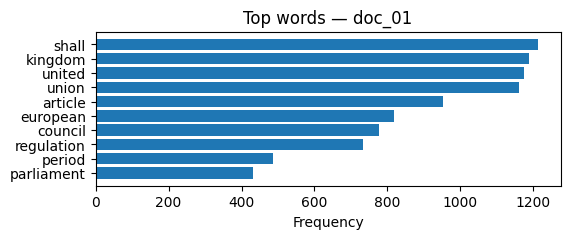

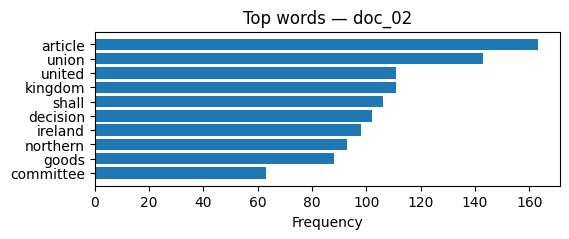

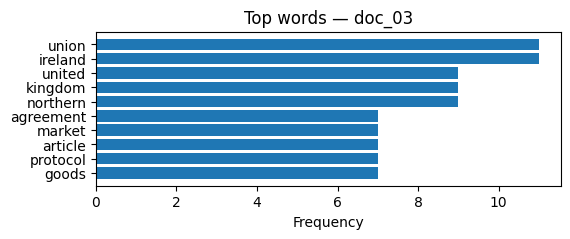

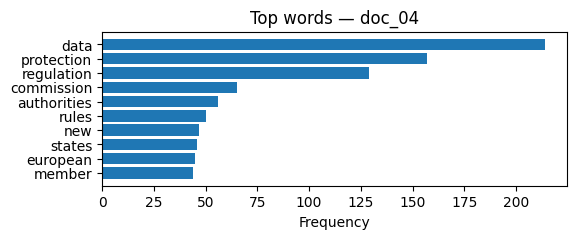

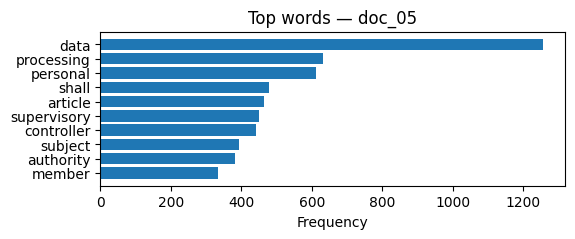

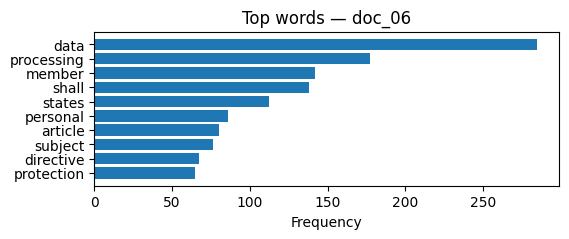

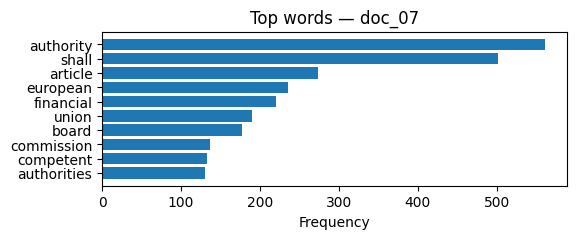

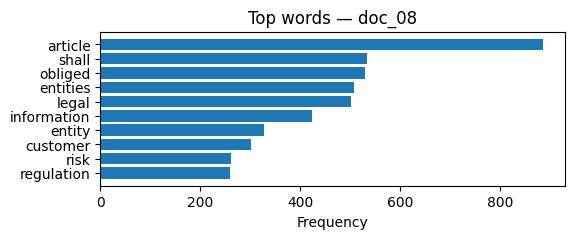

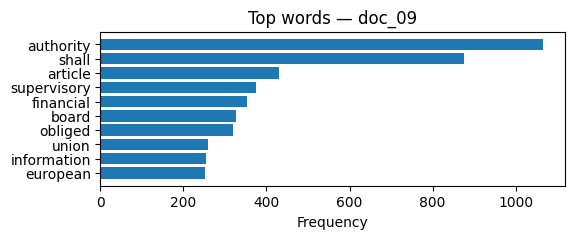

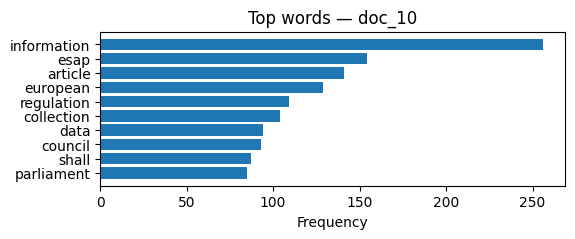

In [39]:
for dt in top_words_dt["doc_id"].unique():
    subset = top_words_dt[top_words_dt["doc_id"] == dt]

    # Adjust teh size of teh plot
    plt.figure(figsize=(6, 2))
    #plt.figure()
    plt.barh(subset["word"], subset["count"])
    plt.title(f"Top words — {dt}")
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()
    plt.show()

It is worth a manula check to determine any further stopwords that could be dropped from the analysis.

##### *<u>Term Frequency x Inverse Document Frequency</u>*

In this analysis the aim is to determine what makes each document different from other documents.<br>
Term Frequency (TF) has already been assessed by counting the frequency of words per document.<br><br>
Inverse Document Frequency (IDF) looks across all documents in the corpus and determines if it is common across all documents, or specific to this one document. It is a way of differentiating specific words by document. A low IDF means it is common across other documents, wheras a high IDF value means it is distinctive to this document.<br><br>
Hence, a high TF-IDF score implies it appears frequently in this document but not in others.<br><br>
It will enable comparison of whether documents differ in their meaning and use of language. In effect it assesses whether or not documents 'cluster' based similar common words.<br><br>
Note this is an intermediate representation used in subsequent exploration.

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    # limit the number of words to 500 to reduce noise and avoid overfitting (keep it meaningful)
    max_features=500
)

tfidf_matrix = vectorizer.fit_transform(doc_text["clean_text"])

##### *<u>Document Similarity (cosine similarity)</u>*
As opposed to comparing documents in terms of the words contained therein, the cosine similarity considers the documents as a whole. <br><br>
Having created a vector for each document from TF-IDF above, the similarity of vectors (angle) can be compared and represented with a value between 1 and 0, where 1 indicates very similar language and 0 represents very different language.<br><br>
Scikitlearn has a specific module for cosine similarity.

In [41]:
from sklearn.metrics.pairwise import cosine_similarity

# pass teh tf-idf matrix (per document) produced earlier, to teh cosine similarity function
similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=doc_text["doc_id"],
    columns=doc_text["doc_id"]
)

similarity_df

doc_id,doc_01,doc_02,doc_03,doc_04,doc_05,doc_06,doc_07,doc_08,doc_09,doc_10
doc_id,,,,,,,,,,
doc_01,1.000000,0.743136,0.543547,0.301637,0.321143,0.303565,0.473941,0.375794,0.412183,0.384022
doc_02,0.743136,1.000000,0.794862,0.199131,0.292266,0.254820,0.418647,0.336123,0.346932,0.291682
doc_03,0.543547,0.794862,1.000000,0.111013,0.133472,0.111014,0.193793,0.156613,0.144136,0.133316
doc_04,0.301637,0.199131,0.111013,1.000000,0.648450,0.642784,0.274768,0.311864,0.320584,0.356315
doc_05,0.321143,0.292266,0.133472,0.648450,1.000000,0.871131,0.463046,0.360649,0.473435,0.335187
doc_06,0.303565,0.254820,0.111014,0.642784,0.871131,1.000000,0.388791,0.350964,0.391079,0.302926
doc_07,0.473941,0.418647,0.193793,0.274768,0.463046,0.388791,1.000000,0.394040,0.830808,0.351692
doc_08,0.375794,0.336123,0.156613,0.311864,0.360649,0.350964,0.394040,1.000000,0.583548,0.452334
doc_09,0.412183,0.346932,0.144136,0.320584,0.473435,0.391079,0.830808,0.583548,1.000000,0.425481


In [42]:
metadata

,file_name,doc_id,source,n_pages,empty_pages,word_count,extraction_success,percent_empty_pages
0,Test05.pdf,doc_01,EUR-Lex,181,0,103895,True,0.0
1,Test06.pdf,doc_02,EUR-Lex,23,0,11641,True,0.0
2,Test07.pdf,doc_03,EUR-Lex,2,0,520,True,0.0
3,Test04.pdf,doc_04,EUR-Lex,18,0,7823,True,0.0
4,Test10.pdf,doc_05,EUR-Lex,88,0,55798,True,0.0
5,Test08.pdf,doc_06,EUR-Lex,20,0,12892,True,0.0
6,Test09.pdf,doc_07,EUR-Lex,36,0,28079,True,0.0
7,Test03.pdf,doc_08,EUR-Lex,111,0,65514,True,0.0
8,Test02.pdf,doc_09,EUR-Lex,90,0,55758,True,0.0
9,Test01.pdf,doc_10,EUR-Lex,22,0,12447,True,0.0


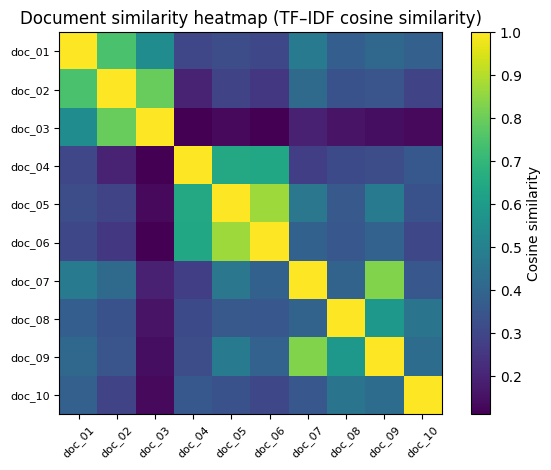

In [44]:
# heatmap of TF-IDF similarity between documents

plt.figure()
plt.imshow(similarity_matrix)
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(doc_text)), doc_text["doc_id"], fontsize=8, rotation=45)
plt.yticks(range(len(doc_text)), doc_text["doc_id"], fontsize=8)
plt.title("Document similarity heatmap (TF–IDF cosine similarity)")
plt.tight_layout()
plt.show()

Observations:

*   Some similarity between document 1 and 2, 7 and 9, 5 and 6, 4 and 5, 4 and 6.



##### *<u>Unsupervised Document Clustering (K-means clustering)</u>*
This technique looks at each document and compares it to other documents for similarity, but does not use categorical metadata (if present) to assist the process. <br>
The k-means cluster technique is provided as a module within the scikitlearn library. It enables a k-means cluster model to be created based on the data provided.

In [45]:
from sklearn.cluster import KMeans

# n is set to 3 - trying to fit into 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
# each docuemnt is assigned to a cluster based on the tf-idf vector previously generated
doc_text["cluster"] = kmeans.fit_predict(tfidf_matrix)

doc_text[["doc_id", "cluster"]]

,doc_id,cluster
0,doc_01,2
1,doc_02,2
2,doc_03,2
3,doc_04,0
4,doc_05,0
5,doc_06,0
6,doc_07,1
7,doc_08,1
8,doc_09,1
9,doc_10,0


It has clustered the ten docuemnts into 3 clusters. As an experiment change to 5 clusters.

In [47]:
# n is set to 5
kmeans = KMeans(n_clusters=5, random_state=42)

doc_text["cluster"] = kmeans.fit_predict(tfidf_matrix)

doc_text[["doc_id", "cluster"]]

,doc_id,cluster
0,doc_01,2
1,doc_02,2
2,doc_03,2
3,doc_04,0
4,doc_05,0
5,doc_06,0
6,doc_07,1
7,doc_08,4
8,doc_09,1
9,doc_10,3


This is very interesting as it only changed the clusters for two of the ten documents.

In [48]:
# list the top terms for each cluster

feature_names = vectorizer.get_feature_names_out()

for cluster_id in sorted(doc_text["cluster"].unique()):
    # it is necessary to use a mask as a numpy array to avoid an error
    mask = (doc_text["cluster"] == cluster_id).to_numpy()

    # sparse matrix subset
    cluster_docs = tfidf_matrix[mask]

    # Mean TF–IDF score per term within this cluster
    mean_tfidf = np.asarray(cluster_docs.mean(axis=0)).ravel()

    top_indices = mean_tfidf.argsort()[-10:][::-1]

    print(f"\nCluster {cluster_id} top terms:")
    for idx in top_indices:
        print(feature_names[idx])


Cluster 0 top terms:
data
protection
processing
personal
regulation
member
controller
shall
article
states

Cluster 1 top terms:
authority
shall
article
board
financial
supervisory
european
supervisors
union
commission

Cluster 2 top terms:
kingdom
united
ireland
union
northern
article
shall
goods
european
protocol

Cluster 3 top terms:
esap
information
eu
esma
article
collection
european
regulation
data
council

Cluster 4 top terms:
article
entities
obliged
legal
beneficial
shall
customer
entity
eli
eu


Change back to 3 clusters

In [49]:
# n is set to 3
kmeans = KMeans(n_clusters=3, random_state=42)

doc_text["cluster"] = kmeans.fit_predict(tfidf_matrix)

doc_text[["doc_id", "cluster"]]

,doc_id,cluster
0,doc_01,2
1,doc_02,2
2,doc_03,2
3,doc_04,0
4,doc_05,0
5,doc_06,0
6,doc_07,1
7,doc_08,1
8,doc_09,1
9,doc_10,0


In [50]:
# list the top terms for each cluster

feature_names = vectorizer.get_feature_names_out()

for cluster_id in sorted(doc_text["cluster"].unique()):
    # it is necessary to use a mask as a numpy array to avoid an error
    mask = (doc_text["cluster"] == cluster_id).to_numpy()

    # sparse matrix subset
    cluster_docs = tfidf_matrix[mask]

    # Mean TF–IDF score per term within this cluster
    mean_tfidf = np.asarray(cluster_docs.mean(axis=0)).ravel()

    top_indices = mean_tfidf.argsort()[-10:][::-1]

    print(f"\nCluster {cluster_id} top terms:")
    for idx in top_indices:
        print(feature_names[idx])


Cluster 0 top terms:
data
processing
protection
regulation
article
personal
esap
shall
information
member

Cluster 1 top terms:
authority
shall
article
financial
obliged
entities
board
union
eu
european

Cluster 2 top terms:
kingdom
united
ireland
union
northern
article
shall
goods
european
protocol


Some words are repeated in the top ten list of each cluster (e.g. regulation, european) showing some similarity between clusters. There are other words appearing discretely in each cluster (e.g. protection, financial, protocol). This is only a list of the top ten words in each cluster, and hence is only indicative of differences between clusters.

##### *<u>Principal Component Analysis (for visualising clusters)</u>*
The use of PCA can enable the TF-IDF vectors (which have very high dimensions) to be compressed into two dimensions for visualisation of the documents on a plot showing the clusters.<br><br>
Scikitlearn has a PCA module that can directly be used based on the TF-IDF vectors created earlier for each document.<br><br> Reducing teh number of dimensions was performed purely to enable visualisation.

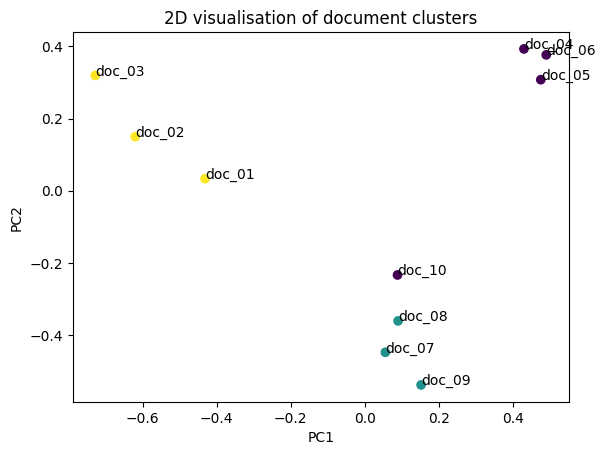

In [51]:
from sklearn.decomposition import PCA

# reduce teh high dimensional tf-idf vector into two dimensions
pca = PCA(n_components=2)
coords = pca.fit_transform(tfidf_matrix.toarray())

plt.figure()
#define x and y axis data, and colour each cluster differently
plt.scatter(coords[:, 0], coords[:, 1], c=doc_text["cluster"])

#add teh doc_id label
for i, doc_id in enumerate(doc_text["doc_id"]):
    plt.text(coords[i, 0], coords[i, 1], doc_id)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D visualisation of document clusters")
plt.show()

There appear to be 3 clear clusters of documents, but it is unexpected that doc_10 would not be grouped with doc 7, 8 & 9 based on its visual proximity on the principal component analysis plot. Looking back to the cosine similarity results, this suggests an issue as there is more similarity with doc 10 to docs 7, 8 and 9 than docs 4, 5 and 6. This will require further analysis.

### **Step 7: Summary of Preliminary EDA**

The analysis has enabled

*   PDF document files to be imported
*   text to be extracted
*   metadata to be stored per document
*   basic descriptive statistics per document and document type
*   enhanced cleaning of text enabling analysis
*   analysis of words and vocabulary per document
*   clustering analysis to determine patterns of similarity

Topic modelling has not been performed as part of EDA on the basis that the corpus was only 10 documents and clustering analysis already assisted in determining thematic differences between documents based on vocabulary.

Lemmatisation was not performed as part of this EDA. It could have been useful to enable conceptual grouping of terms (risk, risks, risky, ...). Whilst this may have reduced the vocabulary size, this could have impaired the actual meaning of this formal, regulatory text, hence was deemed inappropriate.

The EDA did not include sentence counts per document or paragraph length distributions, which could assist in future application design to assist in selecting a chunking approach.

The EDA can be performed on the extended 100 document corpus that will be used in teh project, and the insights should help to inform subsequent application modelling approach.


 .